In [1]:
from pathlib import Path
import sys
import os

PROJECT_ROOT = Path.cwd().parent

import pandas as pd
import csv

import src.constants as Con

In [2]:
from src.data_paths import (
    TEST_RUN_PATH
)

In [3]:
NEW_OUT_PATH = TEST_RUN_PATH / "csvs"

In [4]:
for xls_path in sorted(TEST_RUN_PATH.glob("*.xls")):        # source: parent folder
    df = pd.read_csv(
        xls_path,
        encoding="utf-16",
        sep="\t",
        quoting=csv.QUOTE_NONE,
        engine="python",
    )
    csv_path = NEW_OUT_PATH / xls_path.with_suffix(".csv").name   # dest: csvs/ folder
    df.to_csv(csv_path, index=False, encoding="utf-8")
    print(f"{xls_path.name}: {df.shape} -> {csv_path.name}")


fixations_answers.xls: (1344, 318) -> fixations_answers.csv
IA_answers.xls: (2162, 326) -> IA_answers.csv
messages_answers.xls: (577, 123) -> messages_answers.csv


In [5]:
fix_df = pd.read_csv(NEW_OUT_PATH / "fixations_answers.csv")
ia_df = pd.read_csv(NEW_OUT_PATH / "ia_answers.csv")
msg_df = pd.read_csv(NEW_OUT_PATH / "messages_answers.csv")

C:\Users\deeth\AppData\Local\Temp\ipykernel_33140\270841090.py:2: DtypeWarning: Columns (0: IA_FSA_COUNT_19, 1: IA_FSA_COUNT_20, 2: IA_FSA_COUNT_21, 3: IA_FSA_COUNT_22, 4: IA_FSA_COUNT_23, 5: IA_FSA_COUNT_24, 6: IA_FSA_COUNT_25, 7: IA_FSA_COUNT_26, 8: IA_FSA_COUNT_27, 9: IA_FSA_COUNT_28, 10: IA_FSA_COUNT_29, 11: IA_FSA_COUNT_30, 12: IA_FSA_COUNT_31, 13: IA_FSA_COUNT_32, 14: IA_FSA_COUNT_33, 15: IA_FSA_COUNT_34, 16: IA_FSA_COUNT_35, 17: IA_FSA_COUNT_36, 18: IA_FSA_COUNT_37, 19: IA_FSA_COUNT_38, 20: IA_FSA_COUNT_39, 21: IA_FSA_COUNT_40, 22: IA_FSA_DURATION_19, 23: IA_FSA_DURATION_20, 24: IA_FSA_DURATION_21, 25: IA_FSA_DURATION_22, 26: IA_FSA_DURATION_23, 27: IA_FSA_DURATION_24, 28: IA_FSA_DURATION_25, 29: IA_FSA_DURATION_26, 30: IA_FSA_DURATION_27, 31: IA_FSA_DURATION_28, 32: IA_FSA_DURATION_29, 33: IA_FSA_DURATION_30, 34: IA_FSA_DURATION_31, 35: IA_FSA_DURATION_32, 36: IA_FSA_DURATION_33, 37: IA_FSA_DURATION_34, 38: IA_FSA_DURATION_35, 39: IA_FSA_DURATION_36, 40: IA_FSA_DURATION_37, 41:

## Standardize new-data column names for the pipeline

The new experiment reports use different column names/indexing than the pipeline
expects. Rename them (data name → pipeline name), convert the numeric `answers_order`
to letters, lowercase `participant_id`, and write cleaned CSVs to `csvs/cleaned/`,
which the pipeline then reads:

| new data | pipeline expects |
|---|---|
| `RECORDING_SESSION_LABEL` | `participant_id` |
| `onestopqa_question_id` | `same_critical_span` |
| `practice` | `practice_trial` |
| `correct_answer` (0–3) | `correct_answer_position` |
| `FINAL_ANSWER` (0–3) | `selected_answer_position` |
| `answer_0..answer_3` (0-indexed) | `answer_1..answer_4` (1-indexed) |
| `answer_a..answer_d` | `answer_A..answer_D` |
| `answers_order` = `[2,1,0,3]` (screen→answer index) | `['C','B','A','D']` (letter per screen pos) |

Notes:
- `answer_A..D` are supplied directly, so the base feature that would recompute them
  (`add_answer_text_columns`) is excluded from the run.
- The new experiment has no repeated-reading trials (`repeated_reading_trial` column
  absent), so `remove_repeats` is turned off in the run below.
- `participant_id` is lowercased so it stays consistent everywhere — the button-click
  join also lowercases it, and the last-label / RT merges match on it.

In [6]:
import ast

# Rename map: new-data column (left) -> pipeline column (right).
NEW_DATA_RENAME_MAP = {
    Con.RECORDING_SESSION_LABEL: Con.PARTICIPANT_ID,        # -> participant_id
    "onestopqa_question_id": Con.SAME_CRITICAL_SPAN_COLUMN,  # -> same_critical_span
    "practice": Con.PRACTICE_TRIAL_COLUMN,                   # -> practice_trial
    "correct_answer": Con.CORRECT_ANSWER_POSITION_COLUMN,    # -> correct_answer_position (0-3)
    "FINAL_ANSWER": Con.SELECTED_ANSWER_POSITION_COLUMN,     # -> selected_answer_position (0-3)
    # answers are 0-indexed (answer_0..answer_3); shift up one to the 1-indexed
    # answer_1..answer_4 the pipeline reads (this drops the old answer_0 name).
    f"{Con.ANSWER_PREFIX}0": f"{Con.ANSWER_PREFIX}1",
    f"{Con.ANSWER_PREFIX}1": f"{Con.ANSWER_PREFIX}2",
    f"{Con.ANSWER_PREFIX}2": f"{Con.ANSWER_PREFIX}3",
    f"{Con.ANSWER_PREFIX}3": f"{Con.ANSWER_PREFIX}4",
    # answer_a..answer_d already hold the labelled options; capitalize the letter
    # to the answer_A..answer_D the pipeline uses. Because these are supplied
    # directly, add_answer_text_columns (which would recompute them) is excluded
    # from the run below.
    f"{Con.ANSWER_PREFIX}a": f"{Con.ANSWER_PREFIX}A",
    f"{Con.ANSWER_PREFIX}b": f"{Con.ANSWER_PREFIX}B",
    f"{Con.ANSWER_PREFIX}c": f"{Con.ANSWER_PREFIX}C",
    f"{Con.ANSWER_PREFIX}d": f"{Con.ANSWER_PREFIX}D",
}


def _answers_order_to_letters(value):
    """Convert the new-data numeric answers_order to the letter form the pipeline reads.

    build_exp_inputs.py builds answers_order as screen_position -> original answer
    index (0=A, 1=B, 2=C, 3=D), e.g. [2, 1, 0, 3]. The pipeline expects the *letter*
    at each screen position, e.g. ['C', 'B', 'A', 'D']. Values already in letter form
    are left untouched.
    """
    order = ast.literal_eval(value) if isinstance(value, str) else value
    return [
        Con.ANSWER_LABELS[int(x)] if str(x).lstrip("-").isdigit() else x
        for x in order
    ]


def standardize_new_data_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Rename new-experiment columns to the names the pipeline expects, convert the
    numeric answers_order to letters, and lowercase participant_id.

    Renames are applied in a single pass (so the answer 0->1, 1->2, ... shift
    doesn't collide); columns not present are left untouched. participant_id is
    lowercased here so it stays consistent everywhere downstream (the button-click
    join also lowercases it, and the last-label / RT merges match on it).
    """
    df = df.rename(columns=NEW_DATA_RENAME_MAP)
    if Con.ANSWERS_ORDER_COLUMN in df.columns:
        df[Con.ANSWERS_ORDER_COLUMN] = df[Con.ANSWERS_ORDER_COLUMN].apply(
            _answers_order_to_letters
        )
    if Con.PARTICIPANT_ID in df.columns:
        df[Con.PARTICIPANT_ID] = df[Con.PARTICIPANT_ID].astype(str).str.strip().str.lower()
    return df


CLEANED_DIR = NEW_OUT_PATH / "cleaned"
CLEANED_DIR.mkdir(parents=True, exist_ok=True)

for _name in ["IA_answers.csv", "fixations_answers.csv"]:
    _df = pd.read_csv(NEW_OUT_PATH / _name, low_memory=False)
    _df = standardize_new_data_columns(_df)
    _out = CLEANED_DIR / _name
    _df.to_csv(_out, index=False)
    print(f"{_name}: {_df.shape} -> cleaned/{_name}")


IA_answers.csv: (2162, 326) -> cleaned/IA_answers.csv
fixations_answers.csv: (1344, 318) -> cleaned/fixations_answers.csv


## Run the `data_csv_generation` pipeline on the new experiment inputs

Skeleton for running the existing `src.data_prep.data_csv_generation.main()` pipeline
against the newly-converted IA + fixations CSVs (in `data_raw/testrun_QA/csvs/`) and
writing the result to `data/new_exp_try_runs/`.

**Not expected to run cleanly yet** — see the `TODO` notes in the function for the
known gaps (hardcoded fixation path in `create_fixation_sequence_tags`, button-clicks /
messages inputs, and possible column-name mismatches in the new raw format).

In [7]:
from src.data_prep import data_csv_generation as dcg
from src.data_paths import DATA_DIR

# --- New-experiment inputs (column-standardized CSVs from the cleaning cell) ---
NEW_IA_ANSWERS_PATH = NEW_OUT_PATH / "cleaned" / "IA_answers.csv"
NEW_FIX_ANSWERS_PATH = NEW_OUT_PATH / "cleaned" / "fixations_answers.csv"
NEW_MESSAGES_PATH = NEW_OUT_PATH / "messages_answers.csv"  # not standardized/used yet

# --- Where the processed output goes ---
NEW_EXP_OUT_DIR = DATA_DIR / "new_exp_try_runs"
NEW_EXP_OUT_PATH = NEW_EXP_OUT_DIR / "all_participants.csv"
NEW_EXP_AUX_DIR = NEW_EXP_OUT_DIR / "Auxiliary"

# Base features to skip for the new data. answer_A..D are already supplied by the
# cleaning step (renamed from answer_a..d), so we don't recompute them.
EXCLUDED_BASE_FUNCS = {"add_answer_text_columns"}


def run_new_exp_pipeline(
    ia_answers_path: Path = NEW_IA_ANSWERS_PATH,
    fixations_path: Path = NEW_FIX_ANSWERS_PATH,
    output_path: Path = NEW_EXP_OUT_PATH,
    aux_dir: Path = NEW_EXP_AUX_DIR,
    verbose: bool = True,
):
    """
    Run the data_csv_generation pipeline on the NEW experiment inputs and save the
    result under data/new_exp_try_runs/.

    Runs base + group features, plus the last-label and RT/TFD steps (fed by button
    clicks extracted from the new fixations report). Paragraph-region RT/TFD is off
    since the new experiment has no paragraph-reading screen.
    """
    NEW_EXP_OUT_DIR.mkdir(parents=True, exist_ok=True)
    aux_dir.mkdir(parents=True, exist_ok=True)

    # Run all registered base features except the excluded ones (built from the
    # registry so it stays correct if base features are added/removed).
    base_function_names = [
        name
        for name, entry in dcg.FUNCTION_REGISTRY.items()
        if entry["kind"] == "base" and name not in EXCLUDED_BASE_FUNCS
    ]

    # `fixations_path` is the single canonical fixations report: it feeds both the
    # pupil stats and create_fixation_sequence_tags (group kwargs are forwarded to
    # the feature functions), so all registered group features can run.
    group_function_names = None  # None = all registered group features

    dcg.main(
        ia_answers_path=ia_answers_path,
        output_path=output_path,
        fixations_path=fixations_path,  # feeds pupil stats + fixation-sequence tags
        compute_pupil_stats=True,
        # keep every artifact inside the new-exp folder
        pupil_stats_path=aux_dir / "participant_pupils.csv",
        button_clicks_path=aux_dir / "button_clicks_data.csv",
        last_labels_path=aux_dir / "all_participants_last.csv",
        rt_and_tfd_path=aux_dir / "RT_and_TFD.csv",
        save_auxiliary=True,
        # last-label + RT/TFD features (fed by the button clicks built below)
        add_last=True,
        add_rts=True,
        include_paragraph=False,           # no paragraph-reading screen in new exp
        rebuild_button_clicks=True,
        # button clicks come from the new fixations report itself (self-contained:
        # holds both message-list and fixation columns), not the legacy CSV+TSV.
        button_clicks_fix_csv_path=fixations_path,
        button_clicks_fix_tsv_path=None,               # single source
        button_clicks_msg_participant_col=Con.PARTICIPANT_ID,
        all_answers_is_cumulative=False,               # new ALL_ANSWERS is per-trial
        base_function_names=base_function_names,
        group_function_names=group_function_names,
        # the new experiment has no repeated-reading trials (no repeated_reading_trial
        # column), so the repeat filter is off; practice trials are still removed.
        remove_repeats=False,
        remove_practice=True,
        verbose=verbose,
    )

    if verbose:
        print(f"\n✓ New-exp pipeline output -> {output_path}")
    return output_path


run_new_exp_pipeline()



Building button-click data from raw (forced)…
Loading fix_csv from: E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data_raw\testrun_QA\csvs\cleaned\fixations_answers.csv
No separate fix_tsv: using fix_csv as the single message source
Malformed trial rows: 0
Affected recordings: 0
Rows: 1344 -> 1344
Saved trial_level_df to: E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data\new_exp_try_runs\Auxiliary\button_clicks_data.csv
Final shape: (45, 12)

Loading raw answers from: E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data_raw\testrun_QA\csvs\cleaned\IA_answers.csv

Resolving processing function lists…

Loading fixations report once from: E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data_raw\testrun_QA\csvs\cleaned\fixations_answers.csv
Computing participant pupil stats from preloaded fixations
Saving participant pupils features to: E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data\new_exp_try_runs\Auxiliary\participa

WindowsPath('E:/Technion/QA PROJECT/programming/QA_eyetracking_workspace/data/new_exp_try_runs/all_participants.csv')

## Build model-ready features

Turn the processed IA-level data into the one-row-per-trial modeling feature table
via `save_all_features`, writing it into the new-experiment folder (not the default
`L1_based_data`). It can be read back later with `load_all_features`.

In [9]:
from src.predictive_modeling.answer_correctness.model_data import (
    save_all_features,
    load_all_features,
)

# Model-ready features live alongside the processed data, in the new-exp folder.
NEW_EXP_FEATURES_PATH = NEW_EXP_OUT_DIR / "L1_model_ready_all_features.csv"

processed_ia = pd.read_csv(NEW_EXP_OUT_PATH, low_memory=False)
features_df = save_all_features(processed_ia, output_path=NEW_EXP_FEATURES_PATH, verbose=True)

print("target (is_correct) distribution:")
print(features_df[Con.IS_CORRECT_COLUMN].value_counts(dropna=False).to_string())
features_df.head()


Saved 36 trials x 188 cols to E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data\new_exp_try_runs\L1_model_ready_all_features.csv
target (is_correct) distribution:
is_correct
1    23
0    13


,participant_id,TRIAL_INDEX,text_id_with_q,is_correct,area_dwell_proportion__answer_A,area_dwell_proportion__answer_B,area_dwell_proportion__answer_C,area_dwell_proportion__answer_D,area_dwell_proportion__question,first_encounter_avg_pupil_size_z__answer_A,...,TimeSinceOffset_pure_distance_furthest,TimeSinceOffset_pure_distance_closest,TimeSinceOffset_normalized_correct,TimeSinceOffset_normalized_wrong_mean,TimeSinceOffset_normalized_contrast,TimeSinceOffset_normalized_distance_furthest,TimeSinceOffset_normalized_distance_closest,ANSWER_PRESS_NUMBER,total_answering_RT,total_answering_RT_normalized
0,t1_l1,2,1_4_Adv_1_0,1,0.305979,0.241649,0.246598,0.165567,0.040206,0.685638,...,4146.0,608.0,967.0,445.266667,521.733333,801.400000,225.000000,1,7403,160.934783
1,t1_l1,3,1_4_Adv_2_1,1,0.919247,0.000000,0.000000,0.000000,0.080753,0.765839,...,1997.0,1997.0,199.7,0.000000,199.700000,199.700000,199.700000,1,2551,43.237288
2,t1_l1,4,1_5_Adv_1_0,1,0.407172,0.136147,0.255474,0.126309,0.074897,1.047127,...,2636.0,609.0,1252.5,869.766667,382.733333,777.700000,214.500000,4,6815,283.958333
3,t1_l1,5,1_5_Adv_2_1,1,0.267631,0.246694,0.243664,0.237603,0.004408,0.451495,...,1812.0,251.0,489.5,667.805916,-178.305916,299.833333,63.142857,7,12135,224.722222
4,t1_l1,7,1_8_Adv_1_0,0,0.104232,0.193182,0.177704,0.491575,0.033307,1.180312,...,2100.0,15.0,147.6,164.155769,-16.555769,90.800000,8.225000,1,9383,153.819672


## Train on L1, test on the new data

Fit the logistic-regression correctness model on the **entire** L1 feature set
(no train/test split) and evaluate it on the new-experiment features via
`run_cross_dataset_correctness_bundle`. `feature_cols=None` uses the full feature
set; any feature the new data lacks (e.g. paragraph-region RT/TFD) is dropped
automatically. Metrics, confusion, coefficient, and correlation plots all render.

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
train (L1): (19436, 200) | test (new): (36, 188)
[cross-dataset] dropping 12 feature(s) absent from the test set: ['RT_pure_outside', 'RT_pure_distractor', 'RT_pure_critical', 'RT_normalized_outside', 'RT_normalized_distractor', 'RT_normalized_critical', 'TFD_pure_outside', 'TFD_pure_distractor', 'TFD_pure_critical', 'TFD_normalized_outside', 'TFD_normalized_distractor', 'TFD_normalized_critical']
MODEL: trial_level_log_reg
----------------------------------------------------------------------
Number of test trials: 36
Accuracy: 0.861
Balanced accuracy: 0.824
Positive (correct) trials: 23
Negative (incorrect) trials: 13

Precision / Recall / F1 (per class):
         precision  recall    f1  support
class_0      0.900   0.692 0.783       13
class_1      0.846   0.957 0.898       23

Averages:
  macro    P/R/F1: 0.873 / 0.824 / 0.840
  weighted P/R/F1: 0.866 / 0.861 / 0.856



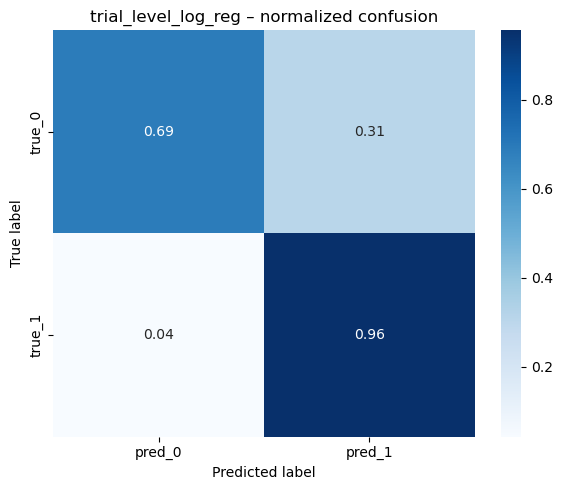

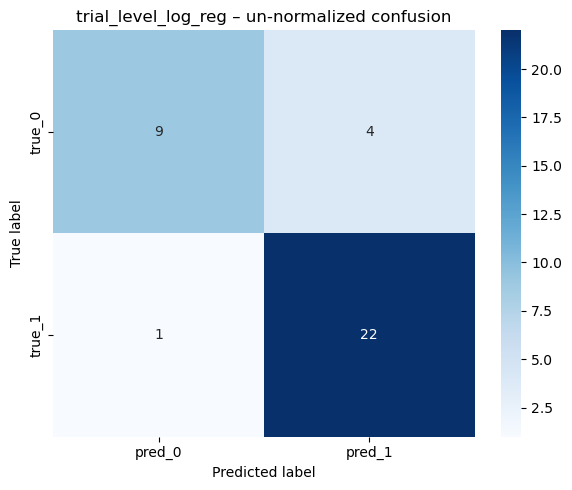

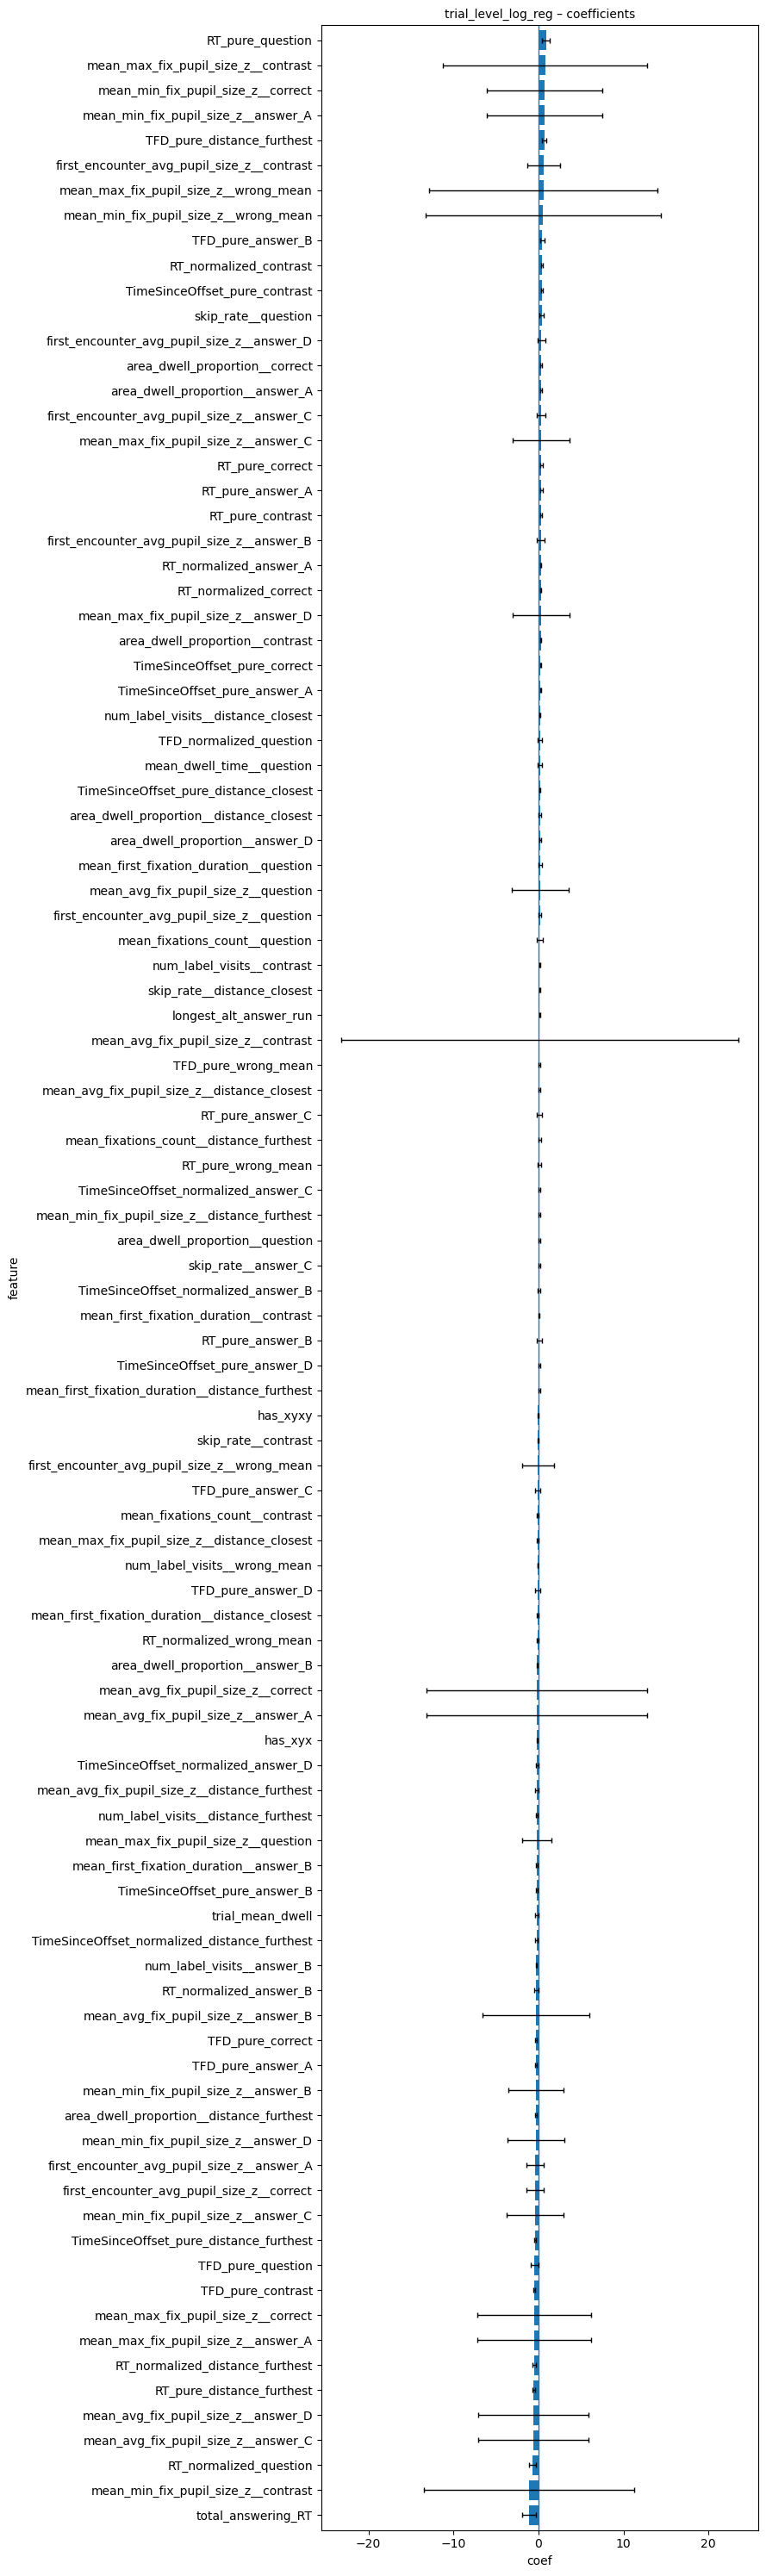

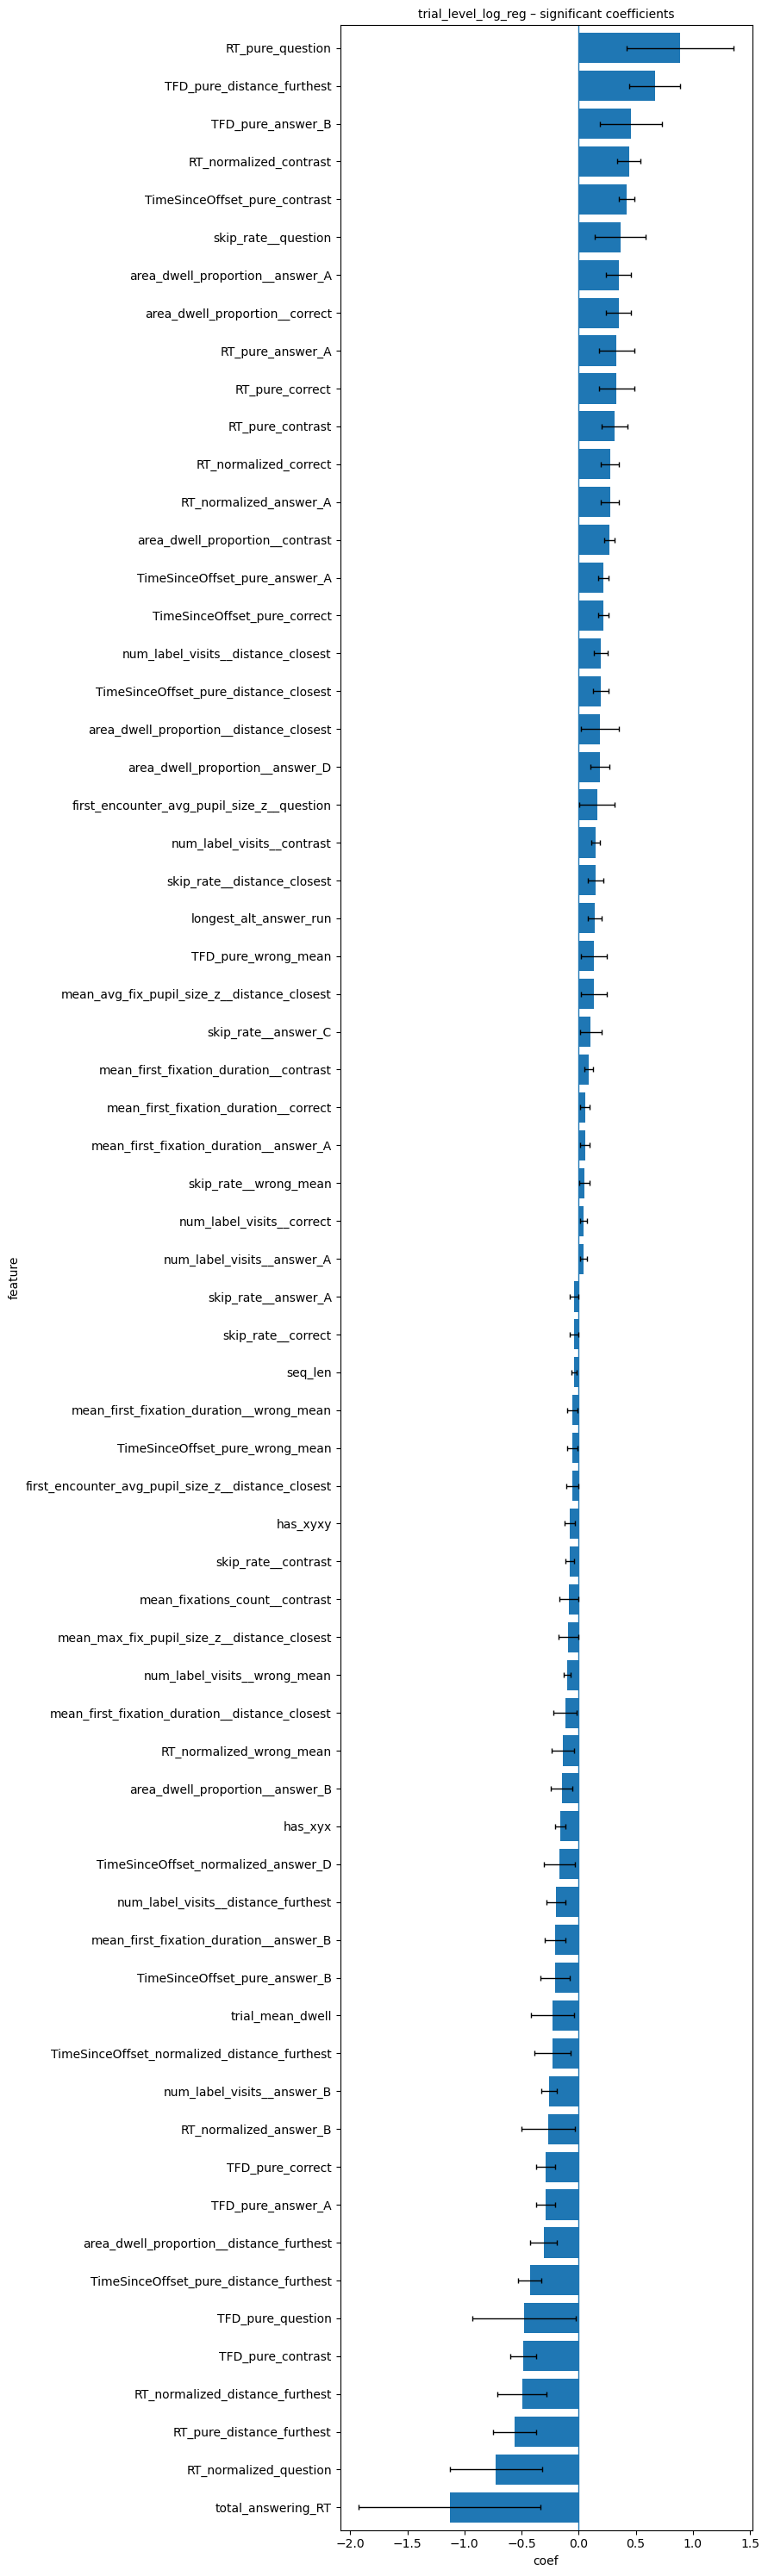

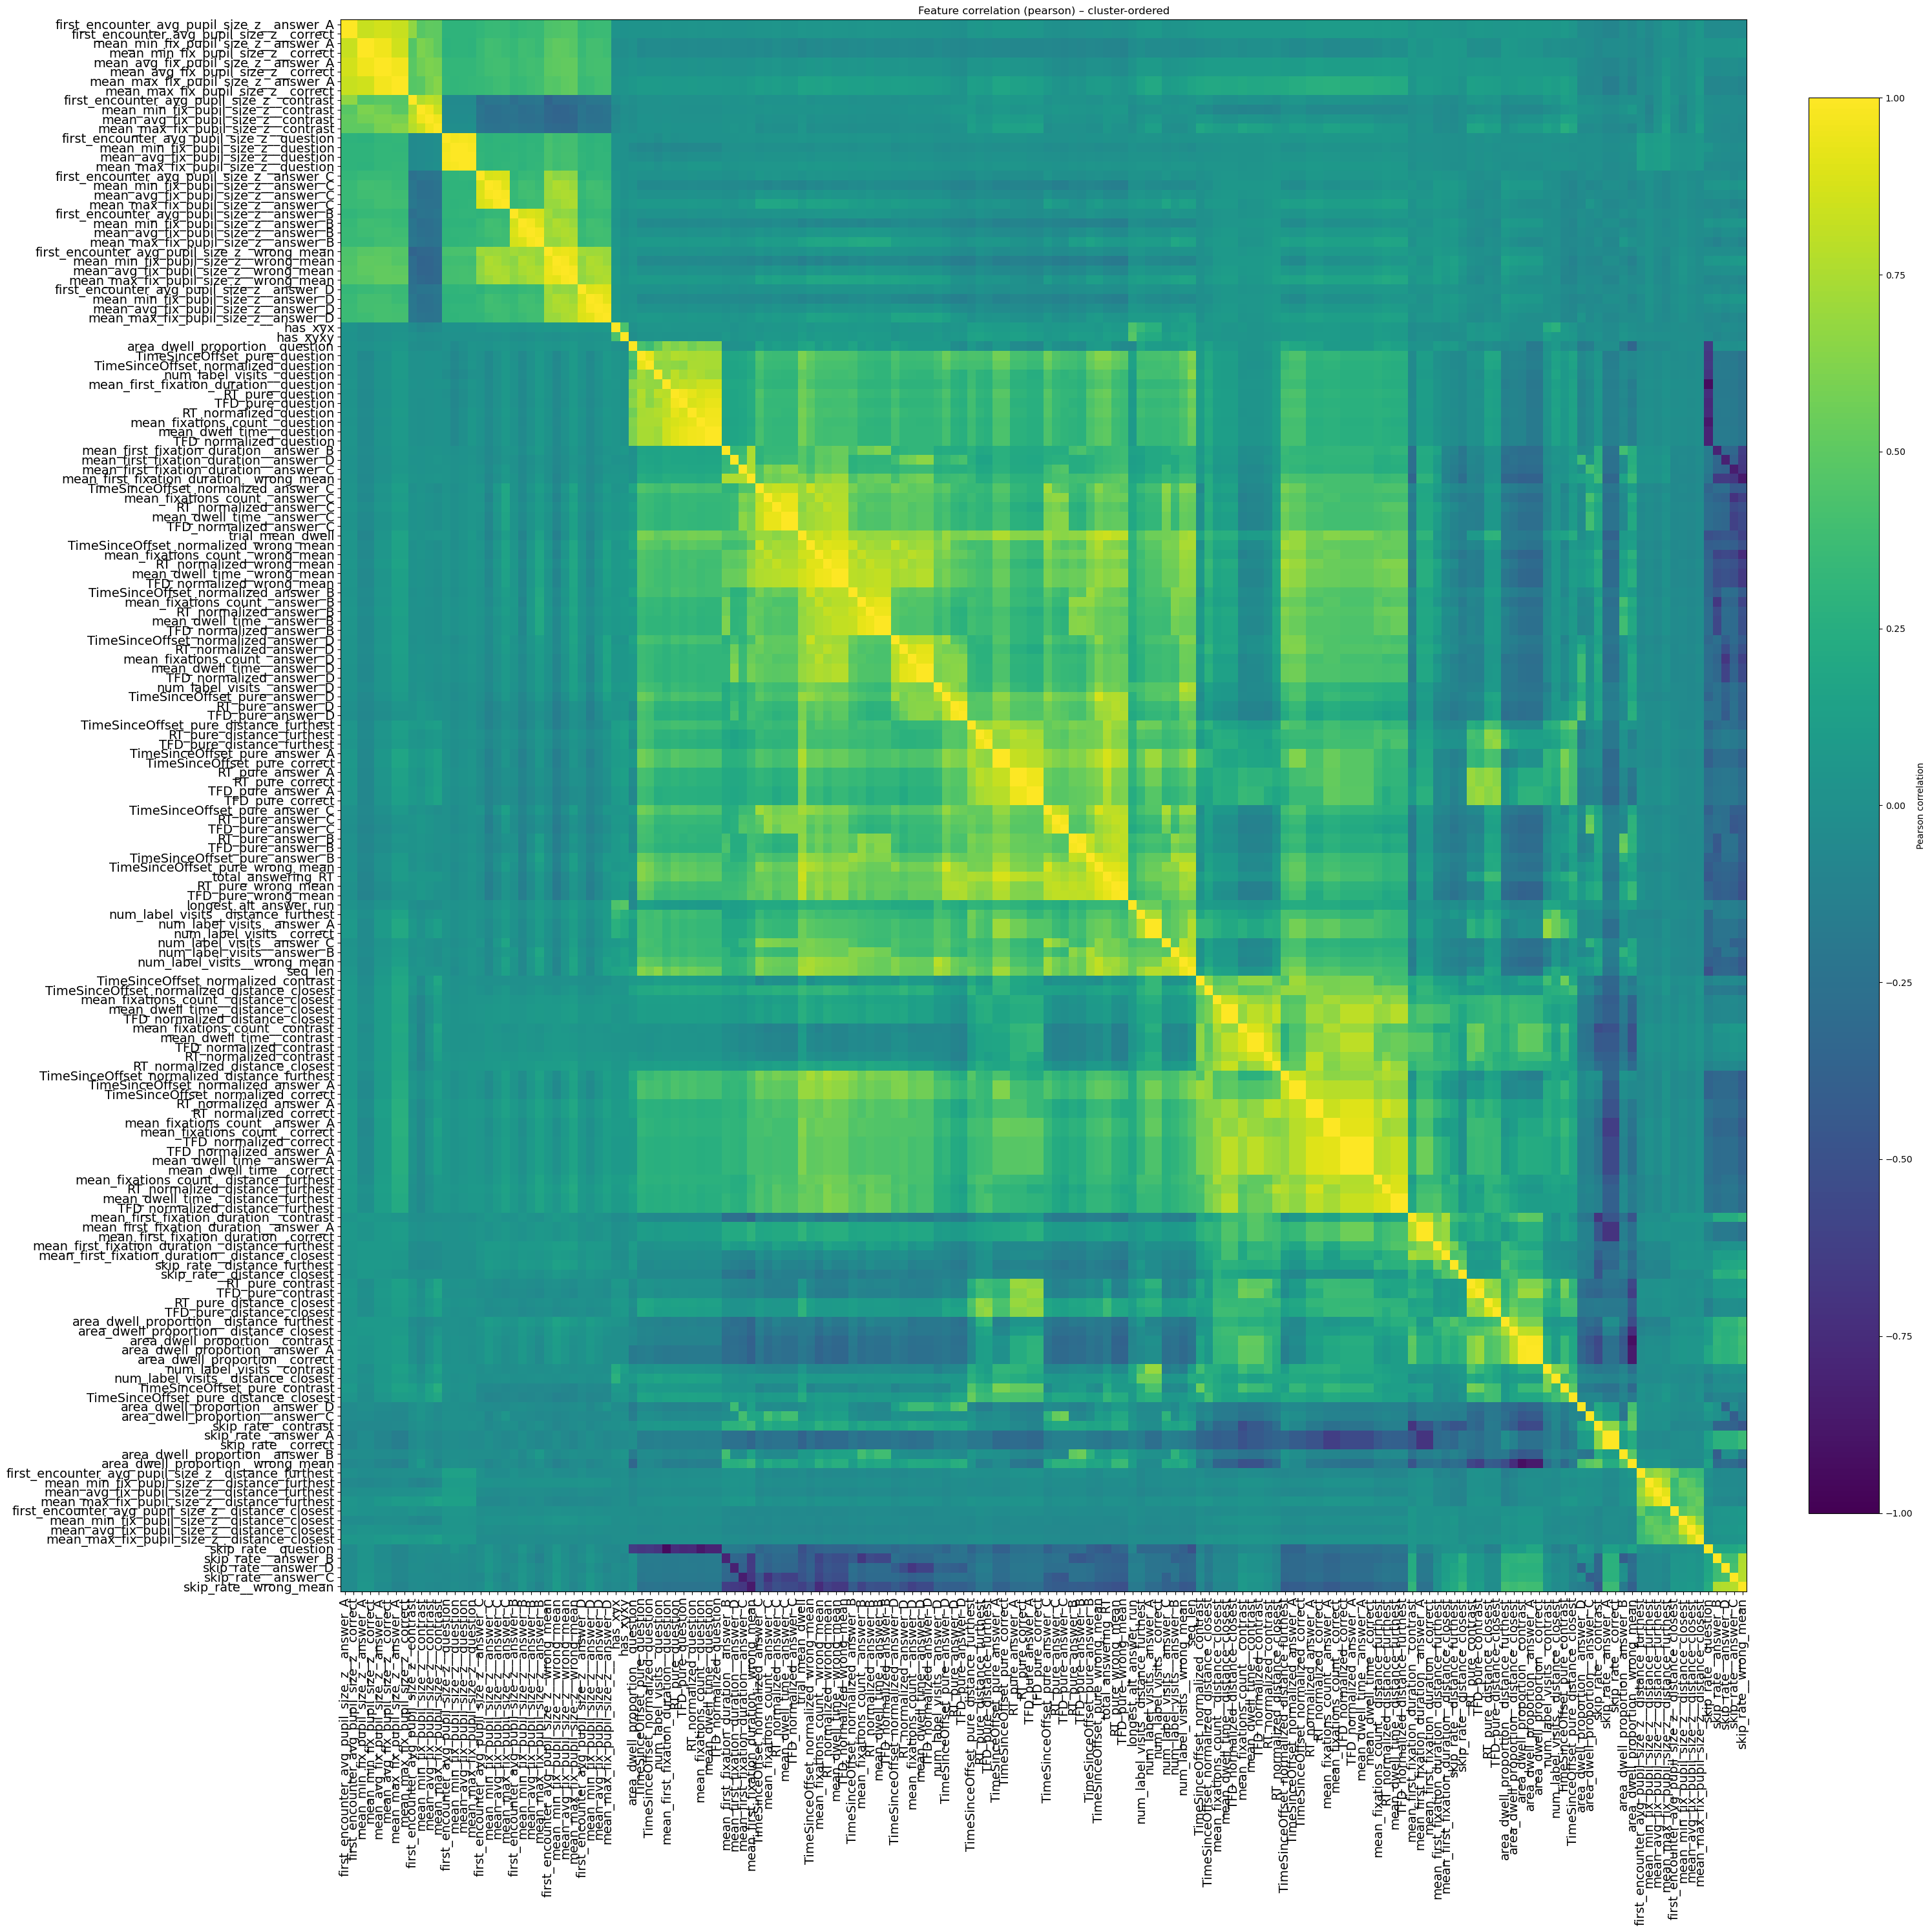

In [ ]:
from src.data_paths import READY_ALL_FEATURES_PATH
from src.predictive_modeling.answer_correctness.run_model_bundles import (
    run_cross_dataset_correctness_bundle,
)

# Train on ALL of L1 (no split), test on the new experiment.
l1_features = load_all_features(READY_ALL_FEATURES_PATH)
new_features = load_all_features(NEW_EXP_FEATURES_PATH)
print(f"train (L1): {l1_features.shape} | test (new): {new_features.shape}")

cross_out = run_cross_dataset_correctness_bundle(
    train_df=l1_features,
    test_df=new_features,
    feature_cols=None,   # None = full feature set (features absent from new data are dropped)
    save=False,          # set True to also write plots/CSVs under reports/
    close=False,         # keep figures open so they render in the notebook
)
